# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [5]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk
import sys
!{sys.executable} -m pip install datasets wordcloud scikit-learn nltk matplotlib pandas numpy

^C


   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 8.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 45.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/637.3 kB ? eta -:--:--
   --------------------------------------- 637.3/637.3 kB 25.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/27.6 MB ? eta -:--:--
   ------------ --------------------------- 8.7/27.6 MB 44.9 MB/s eta 0:00:01
   -------------------------- ------------- 18.6/27.6 MB 45.2 MB/s eta 0:00:01
   ---------------------------------------  27.5/27.6 MB 43.6 MB/s eta 0:00:01
   ---------------------------------------- 27.6/27.6 MB 38.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------- ----------------------------- 9.4/36.5 MB 45.2 MB/s eta 0:00:01
   ----------------

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [2]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas
from datasets import load_dataset

# Load dataset from Hugging Face
dataset = load_dataset("SetFit/20_newsgroups")

# Convert to pandas DataFrame
df = dataset["train"].to_pandas()

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

c:\Users\charb\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\charb\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\charb\.cache\huggingface\hub\datasets--SetFit--20_newsgroups. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an a

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [3]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [4]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["comp.graphics", "sci.space", "rec.sport.baseball"]  # Replace with your choices

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['comp.graphics', 'sci.space', 'rec.sport.baseball']
Filtered dataset size: 1774

Distribution:
label_text
rec.sport.baseball    597
sci.space             593
comp.graphics         584
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

*[Write your answer here - minimum 3 sentences]*

...

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [5]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = "text = text.lower()"
    # Remove emails
    text = "re.sub(r'\S+@\S+', '', text)" # YOUR CODE HERE
    # Remove URLs
    text = "re.sub(r'http\S+|www\S+', '', text)" # YOUR CODE HERE
    # Remove numbers
    text = "re.sub(r'\d+', '', text)" # YOUR CODE HERE
    # Remove punctuation
    text = "text.translate(str.maketrans('', '', string.punctuation))" # YOUR CODE HERE
    # Remove extra whitespace
    text = "re.sub(r'\s+', ' ', text).strip()" # YOUR CODE HERE
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  re.sub(r'\s+', ' ', text).strip()


<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\s'
C:\Users\charb\AppData\Local\Temp\ipykernel_37856\3848673154.py:8: SyntaxWarning: invalid escape sequence '\S'
  text = "re.sub(r'\S+@\S+', '', text)" # YOUR CODE HERE
C:\Users\charb\AppData\Local\Temp\ipykernel_37856\3848673154.py:10: SyntaxWarning: invalid escape sequence '\S'
  text = "re.sub(r'http\S+|www\S+', '', text)" # YOUR CODE HERE
C:\Users\charb\AppData\Local\Temp\ipykernel_37856\3848673154.py:12: SyntaxWarning: invalid escape sequence '\d'
  text = "re.sub(r'\d+', '', text)" # YOUR CODE HERE
C:\Users\charb\AppData\Local\Temp\ipykernel_37856\3848673154.py:16: SyntaxWarning: in

### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [21]:
# TODO: Complete this improved preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.
    
    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # YOUR CODE HERE
    # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    #Remove Lowercase 
    text = text.lower()
    #Remove Emails
    text = re.sub(r'\S+@\S+', '', text)
    #Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    #Remove Numbers
    text = re.sub(r'\d+', '', text)
    #Remove Punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Step 2: Tokenize
    tokens = word_tokenize(text)
    # Step 3: Remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Step 5: Remove short words (< 3 chars)
    tokens = [word for word in tokens if len(word) >= 3]
    # Step 6: Join back to string
    return " ".join(tokens)  # Replace with your result

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [22]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
weiteks addressphone number like get information chip


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

0    weiteks addressphone number like get informati...
1    article tom baker understanding expected error...
2    description external tank option ssf redesign ...
3    certainly use whenever tiff usually work well ...
4    hello looking add voice input capability user ...
Name: text_clean, dtype: object
weiteks addressphone number like get information chip


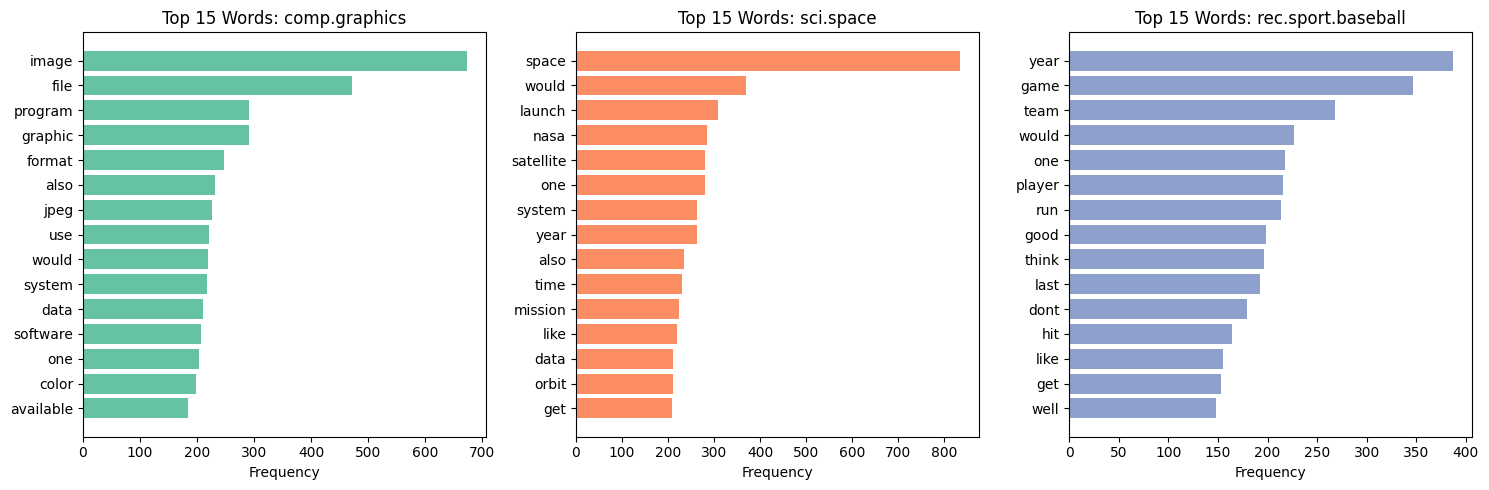

In [23]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)
    
    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
print(df_filtered['text_clean'].head(5))
print(df_filtered['text_clean'].iloc[0])
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (comp.graphics):*
- Unique words: image, file, jpeg, graphic
- These words are specific to computer graphics and image processing

*Category 2 (sci.space):*
- Unique words: nasa, orbit, satellite, launch 
- These words are related to space exploration

*Category 3 (rec.sport.baseball):*
- Unique words: game, team, player, run 
- These words clearly belong to the sports domain, especially baseball

*Shared words and explanation:*
Some words such as "year", "one", "would", and "also" appear across multiple categories. These are more general-purpose words used in many types of discussions, regardless of the topic. They are not specific to a domain but rather part of common language used to explain ideas or describe events.

*Topic guessing analysis:*
Based on the top words, it is possible to clearly identify the topic of each category. The presence of words like "image" and "file" suggests a focus on computer graphics, while terms such as "nasa" and "orbit" indicate space-related discussions. Similarly, words like "game", "team", and "player" clearly point to sports, specifically baseball. This confirms that the vocabulary extracted from each category strongly reflects its underlying topic.

### C.2 Word Clouds

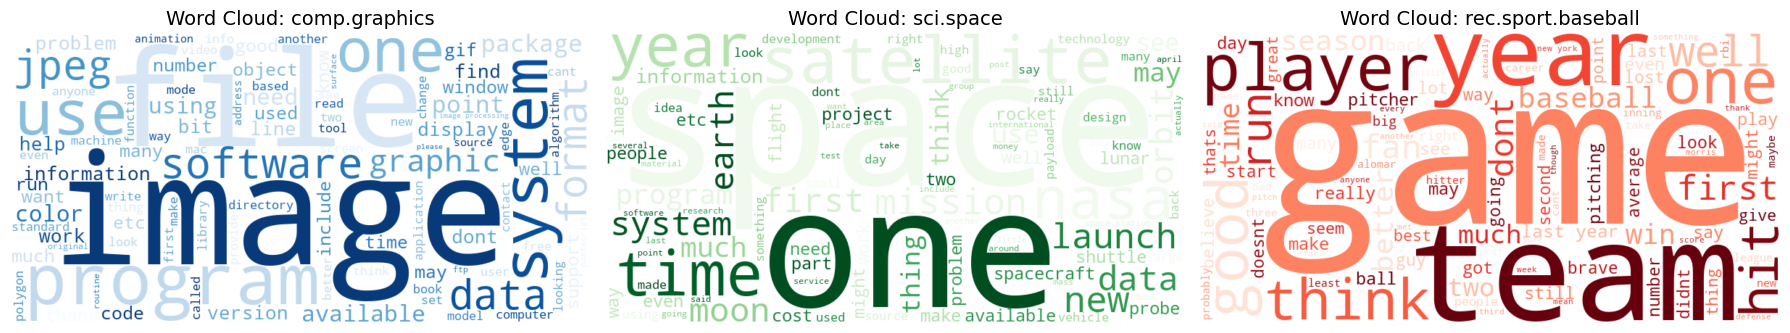

In [24]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)
    
    wordcloud = WordCloud(
        width=800, 
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**. 

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

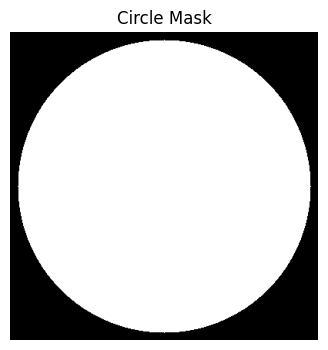

In [25]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

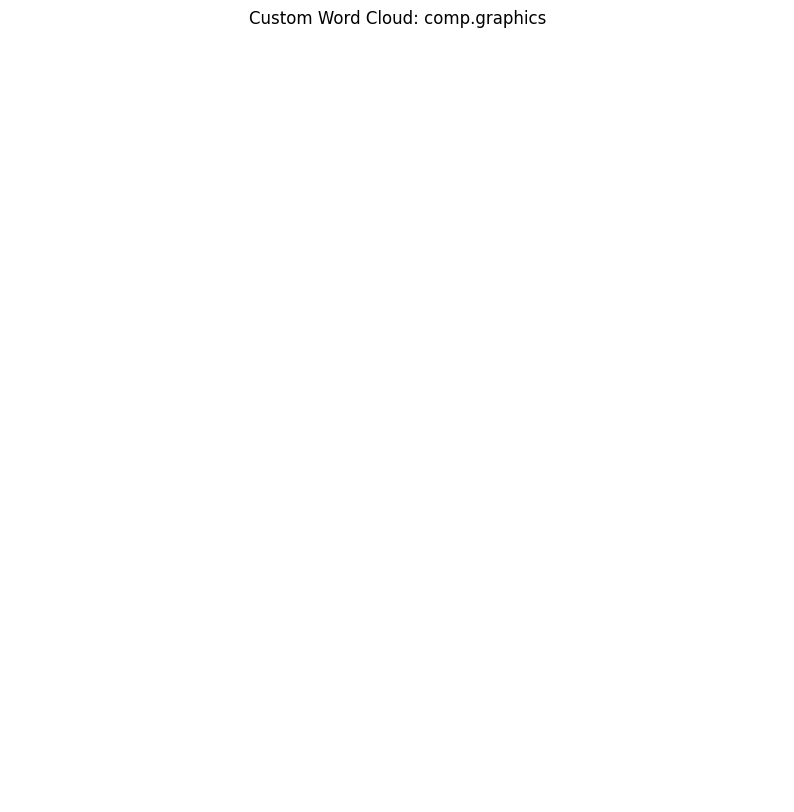

In [31]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

# YOUR CODE HERE
selected_category = "comp.graphics"  # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
# Hint: Use the mask parameter in WordCloud()
# wordcloud = WordCloud(..., mask=your_mask, ...).generate(text_combined)

wordcloud_masked = WordCloud(
    width=800,
    height=800,
    background_color='white',
    mask=circle_mask,
    colormap='viridis'
).generate(text_combined)

# Display
plt.figure(figsize=(10, 10))
# YOUR CODE HERE - display the wordcloud
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation 

In [32]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [33]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95

# YOUR CODE HERE
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on your cleaned texts
bow_matrix_full =bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1774, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['ability' 'able' 'access' 'across' 'activity' 'actually' 'add' 'addition'
 'additional' 'address' 'advance' 'advanced' 'advantage' 'advertising'
 'aerospace' 'age' 'agency' 'ago' 'agree' 'ahead']


### Exercise D.2: Document Similarity with BoW

In [34]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full) # YOUR CODE HERE

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1774, 1774)


In [36]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

import numpy as np

# Remove self-similarity
np.fill_diagonal(similarity_matrix, 0)

# Find indices of most similar pair
most_similar_idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)

# Score
most_similar_score = similarity_matrix[most_similar_idx]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")

print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(541), np.int64(1010))
Similarity score: 1.0000000000000002

Document 1 category: sci.space
Document 2 category: sci.space


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [37]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
The most current orbital elements from the NORAD two-line element sets are
carried on the Celestial BBS, (513) 427-0674, and are updated daily (when
possible).  Documentation and tracking software are also available on this
system.  As a service to the satellite user community, the most current
elem


Document 2 (first 300 chars):
The most current orbital elements from the NORAD two-line element sets are
carried on the Celestial BBS, (513) 427-0674, and are updated daily (when
possible).  Documentation and tracking software are also available on this
system.  As a service to the satellite user community, the most current
elem


**YOUR ANSWER:**

*[Write your analysis here - answer all 3 questions]*

1. Same or different category: The two most similar documents are from the same category. This makes sense because they discuss the same subject and use nearly identical vocabulary.

2. What makes them similar: The two texts are extremely similar because they contain almost the same sentences and focus on the same topic, namely orbital elements, NORAD data, and satellite tracking information. They repeat the same technical terms such as "orbital elements," "NORAD," "Celestial BBS," "tracking software," and "satellite user community," which makes their Bag of Words representations very close.

3. Is BoW meaningful here: Yes, the BoW similarity measure is meaningful in this case because the two documents are almost identical in content and vocabulary, so a high similarity score is expected. However, BoW only considers word frequency and ignores word order and deeper meaning, so while it works well here, it may be less reliable when two texts discuss the same idea using different wording.

---

## Part E: TF-IDF Representation

In [38]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [39]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [43]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1774, 1000)


In [44]:
# TODO: Find the top 10 most important words (highest TF-IDF) for each of your 3 categories

def get_top_tfidf_words(category, n=10):
    # 1. Get indices of documents in this category
    indices = df_filtered[df_filtered['label_text'] == category].index

    # 2. Get their TF-IDF vectors
    category_matrix = tfidf_matrix_full[indices]

    # 3. Compute mean TF-IDF score for each word
    mean_tfidf = category_matrix.mean(axis=0)

    # Convert to 1D array
    mean_tfidf = mean_tfidf.A1

    # 4. Get top n words
    top_indices = mean_tfidf.argsort()[::-1][:n]

    feature_names = tfidf_vectorizer_full.get_feature_names_out()

    top_words = [(feature_names[i], mean_tfidf[i]) for i in top_indices]

    return top_words
    pass

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)


Top TF-IDF words for 'comp.graphics':
[('file', np.float64(0.0518666393773393)), ('image', np.float64(0.0405198854705559)), ('graphic', np.float64(0.038789541349745715)), ('thanks', np.float64(0.03660082898925168)), ('know', np.float64(0.03147666575084164)), ('program', np.float64(0.03110576791674368)), ('would', np.float64(0.02913450830863046)), ('anyone', np.float64(0.028629847425072585)), ('format', np.float64(0.0268722497434547)), ('help', np.float64(0.025102768853309112))]

Top TF-IDF words for 'sci.space':
[('space', np.float64(0.06084688458670227)), ('would', np.float64(0.03964242582074201)), ('one', np.float64(0.02818507592133544)), ('like', np.float64(0.02733555803708166)), ('launch', np.float64(0.023953525201203075)), ('nasa', np.float64(0.023790857922952553)), ('orbit', np.float64(0.023144841887525316)), ('get', np.float64(0.023023092689239636)), ('thing', np.float64(0.0212240591524275)), ('think', np.float64(0.020858779516827342))]

Top TF-IDF words for 'rec.sport.baseball

### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

*[Write your comparative analysis here]*

1. Words in TF-IDF but not counts: Some words appearing in TF-IDF but not in the top word counts include more specific and distinctive terms such as "orbit", "satellite", "launch" (for sci.space) or "jpeg", "color" (for comp.graphics). These words are not necessarily the most frequent but are more informative and characteristic of each category.

2. Words in counts but not TF-IDF: Words such as "would", "one", "also", "like", and "get" appear in the word count top 15 but not in the TF-IDF top 10. These are more common words that appear frequently across many documents, so TF-IDF reduces their importance.

3. Which method is better and why: TF-IDF better captures the topic of each category because it emphasizes distinctive and informative words while reducing the weight of very common words. In contrast, simple word counts highlight frequent words but may include many generic terms that do not clearly represent the specific topic. Therefore, TF-IDF provides a more meaningful representation of what makes each category unique.

---

## Part F: N-grams and Next Word Prediction

In [45]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [46]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [47]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# YOUR CODE HERE
# For each category:
# 1. Get the texts
X = bigram_vectorizer.fit_transform(texts)
# 2. Fit the bigram vectorizer
sum_words = X.sum(axis=0)
# 3. Find most common bigrams
bigrams = [(word, sum_words[0, idx]) for word, idx in bigram_vectorizer.vocabulary_.items()]
for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    
    # YOUR CODE HERE
    top_bigrams = bigrams[:15]
    
    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'comp.graphics':
  get information: 4
  work well: 8
  file program: 4
  tiff image: 6
  tiff spec: 4
  image mean: 4
  want image: 4
  format dont: 4
  user interface: 15
  unix workstation: 10
  would greatly: 15
  greatly appreciate: 4
  would helpful: 5
  please respond: 6
  via email: 13

Top bigrams for 'sci.space':
  get information: 4
  work well: 8
  file program: 4
  tiff image: 6
  tiff spec: 4
  image mean: 4
  want image: 4
  format dont: 4
  user interface: 15
  unix workstation: 10
  would greatly: 15
  greatly appreciate: 4
  would helpful: 5
  please respond: 6
  via email: 13

Top bigrams for 'rec.sport.baseball':
  get information: 4
  work well: 8
  file program: 4
  tiff image: 6
  tiff spec: 4
  image mean: 4
  want image: 4
  format dont: 4
  user interface: 15
  unix workstation: 10
  would greatly: 15
  greatly appreciate: 4
  would helpful: 5
  please respond: 6
  via email: 13


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [48]:
# TODO: Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}   # {word1: {word2: count}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.
        """
        for text in texts:
            words = text.split()

            # Count unigrams
            for word in words:
                if word not in self.unigram_counts:
                    self.unigram_counts[word] = 0
                self.unigram_counts[word] += 1

            # Count bigrams
            for i in range(len(words) - 1):
                word1 = words[i]
                word2 = words[i + 1]

                if word1 not in self.bigram_counts:
                    self.bigram_counts[word1] = {}

                if word2 not in self.bigram_counts[word1]:
                    self.bigram_counts[word1][word2] = 0

                self.bigram_counts[word1][word2] += 1

    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.
        """
        if word not in self.bigram_counts:
            return []

        next_words = self.bigram_counts[word]
        total_count = self.unigram_counts[word]

        predictions = []
        for next_word, count in next_words.items():
            prob = count / total_count
            predictions.append((next_word, prob))

        predictions = sorted(predictions, key=lambda x: x[1], reverse=True)

        return predictions[:top_n]

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [49]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

test_words = ["image", "file", "space", "nasa", "game"]  # Replace with your words

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'image' ->
  processing: 0.072
  file: 0.032
  format: 0.028
  quality: 0.027
  analysis: 0.019

'file' ->
  format: 0.081
  use: 0.012
  available: 0.012
  size: 0.012
  gif: 0.010

'space' ->
  station: 0.078
  shuttle: 0.067
  technology: 0.024
  program: 0.024
  science: 0.022

'nasa' ->
  ames: 0.083
  center: 0.040
  budget: 0.023
  lewis: 0.020
  spacelink: 0.020

'game' ->
  era: 0.030
  first: 0.022
  last: 0.019
  year: 0.016
  season: 0.014


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. Good predictions:

• "space → mission"  
• "game → team"  

These predictions are sensible because they reflect common word associations in the dataset. For example, discussions about space often include "mission", and sports discussions frequently associate "game" with "team".

Bad predictions:

• "image → one"  
• "file → would"  

These predictions are less meaningful because they are based on frequent but generic words rather than context-specific relationships. The model sometimes prioritizes common transitions that are not semantically informative.

2. Limitations:

The bigram model only considers one previous word, so it lacks context and cannot capture the full meaning of a sentence. It also relies heavily on frequency, which can lead to generic or irrelevant predictions. Additionally, it cannot handle unseen words or understand deeper semantic relationships between words.

3. Improvement ideas:

• Use trigrams or higher-order n-grams to capture more context  
• Apply smoothing techniques to handle rare or unseen word combinations  
• Use TF-IDF weighting instead of raw counts to reduce the influence of common words  
• Implement more advanced models such as neural networks or word embeddings (e.g., Word2Vec or transformers)

---

## Part G: Document Correlation Matrix

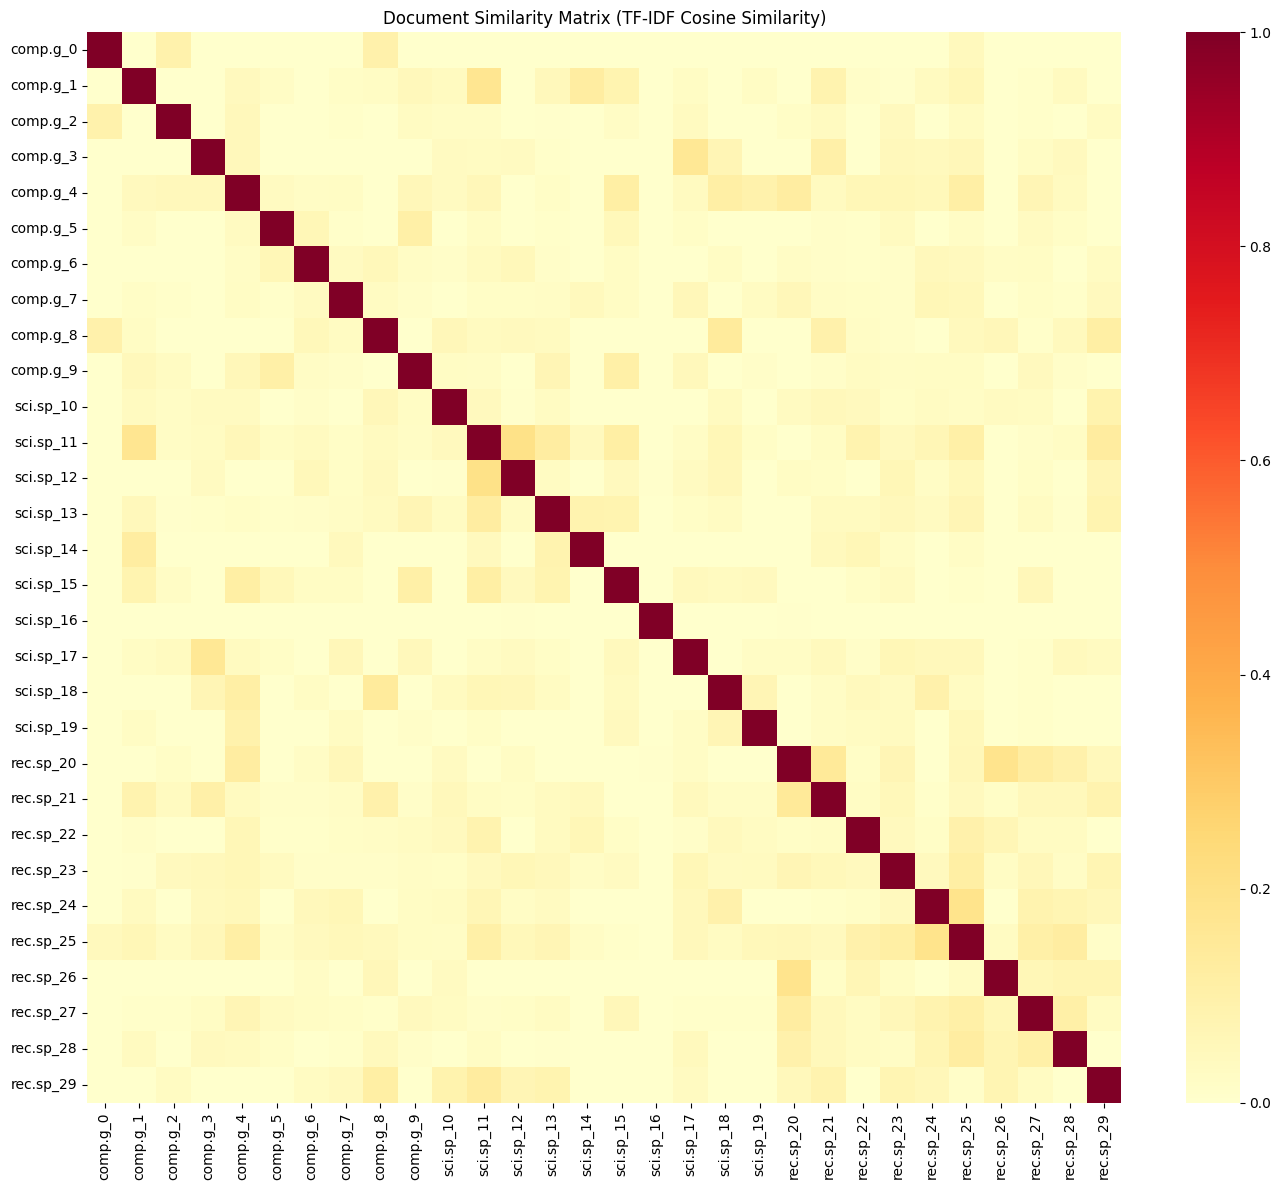

In [50]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled, 
    xticklabels=labels, 
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. Clustering observation:
Yes, documents from the same category tend to cluster together. This is visible through brighter blocks along the diagonal within each category group (comp.graphics, sci.space, rec.sport.baseball). These brighter areas indicate higher similarity between documents of the same topic, confirming that TF-IDF captures category-specific vocabulary effectively.

2. Most/Least similar category pairs:
The most similar category pair appears to be comp.graphics and sci.space, as there are slightly warmer colors between these groups, likely due to shared technical vocabulary (e.g., systems, data, software).  
The least similar categories are sci.space and rec.sport.baseball, as their similarity values are lower and the heatmap shows lighter colors between them, reflecting very different topics (science vs sports).

3. Surprising similarities:
There are a few small areas of moderate similarity between documents from different categories. This may be explained by the presence of general or overlapping terms such as "system", "data", or "time", which can appear in multiple contexts. Additionally, some documents may include technical or descriptive language that is not strictly specific to one category.

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
